In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-l8e6lkqz because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
ACOUSTIC_DIR = GENERATED_DIR / "acoustic"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic_frame"

In [3]:
DATA_SIZE = 10 # TODO: remove; just for prototyping

acoustic_paths = sorted(ACOUSTIC_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(acoustic_paths), len(linguistic_paths)

(10, 10)

In [4]:
acoustic_arrays = [np.load(path) for path in acoustic_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

In [5]:
# Truncate, same length
acoustic_arrays = [ac_arr[:len(ln_arr)] for ac_arr, ln_arr in zip(acoustic_arrays, linguistic_arrays)]

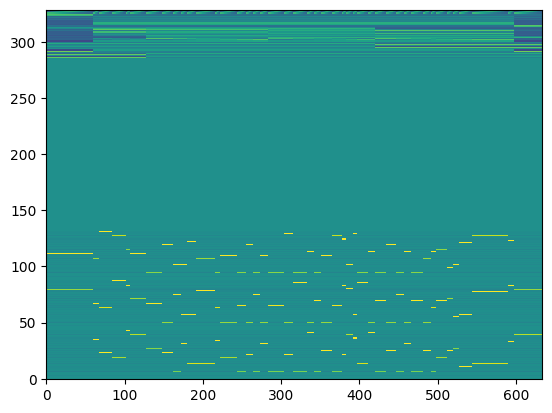

In [6]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [7]:
linguistic_arrays[0].shape

(634, 329)

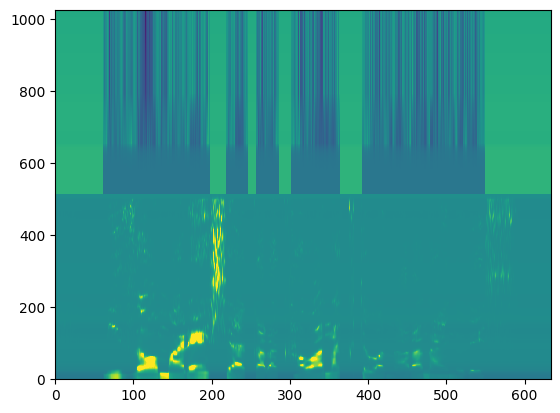

In [8]:
plt.imshow(acoustic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [9]:
f0_arrays = [arr[:, 0:0 + 1] for arr in acoustic_arrays]
sp_arrays = [arr[:, 1:1 + 513] for arr in acoustic_arrays]
ap_arrays = [arr[:, 1 + 513: 1 + 513 + 513] for arr in acoustic_arrays]

In [10]:
dataset = tf.data.Dataset.from_tensor_slices(
    (
        np.concatenate(linguistic_arrays, axis=0),
        (
            np.concatenate(f0_arrays, axis=0),
            np.concatenate(sp_arrays, axis=0),
            np.concatenate(ap_arrays, axis=0),
        )
    )
).shuffle(2048).batch(1024)

2022-10-15 10:59:42.192875: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-15 10:59:42.254508: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-15 10:59:42.254782: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-15 10:59:42.256637: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate 

In [47]:
from tensorflow.keras.layers import *

def _extend(ipt, name):
    
    resid_feature = Reshape((1, -1))(Dense(32, activation='relu', name=f'{name}_res_f')(ipt))
    resid_space = Reshape((-1, 1))(Dense(16, activation='relu', name=f'{name}_res_s')(ipt))
    
    x = Reshape((1, -1))(ipt)
    x = Conv1DTranspose(128, 7, strides=4, padding='same', name=f'{name}_c_1')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(32, 7, strides=4, padding='same')(x)
    x = Add(name=f'{name}_add')([x, resid_feature, resid_space])
    x = ReLU()(x)
    x = Conv1DTranspose(8, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(2, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(1, 3, strides=2, padding='same')(x)
    x = Flatten()(x)
    last = Dense(1)(x)
    x = Concatenate(name=f'{name}_out')([x, last])
    return x


def get_model(input_dim = 329, f0_dim=1, sp_dim=513, ap_dim=513):
    ipt = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256,)(ipt)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(256,)(x)
    x = tf.keras.layers.ReLU()(x)
    
    sp_out = _extend(x, 'sp')
    ap_out = _extend(x, 'ap')
    
    x = tf.keras.layers.Dense(64,)(x)
    x = tf.keras.layers.ReLU()(x)

    f0_out = tf.keras.layers.Dense(1, name="f0")(x)

    model = tf.keras.models.Model(inputs=ipt, outputs=(f0_out, sp_out, ap_out))
    return model

model = get_model()
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 329)]        0           []                               
                                                                                                  
 dense_43 (Dense)               (None, 256)          84480       ['input_8[0][0]']                
                                                                                                  
 re_lu_69 (ReLU)                (None, 256)          0           ['dense_43[0][0]']               
                                                                                                  
 dense_44 (Dense)               (None, 256)          65792       ['re_lu_69[0][0]']               
                                                                                            

 nspose)                                                                                          
                                                                                                  
 dense_47 (Dense)               (None, 64)           16448       ['re_lu_70[0][0]']               
                                                                                                  
 flatten_14 (Flatten)           (None, 512)          0           ['conv1d_transpose_57[0][0]']    
                                                                                                  
 flatten_15 (Flatten)           (None, 512)          0           ['conv1d_transpose_61[0][0]']    
                                                                                                  
 re_lu_79 (ReLU)                (None, 64)           0           ['dense_47[0][0]']               
                                                                                                  
 dense_45 

In [48]:
from tensorflow.keras.losses import MeanSquaredError as MSE

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=(MSE(), MSE(), MSE()),
              metrics=['MAE'])

In [ ]:
model.fit(dataset, epochs=1000)

Epoch 1/1000
8/8 [==============================] - 1s 21ms/step - loss: 2.7096 - f0_loss: 0.6093 - sp_out_loss: 1.2081 - ap_out_loss: 0.8923 - f0_MAE: 0.6287 - sp_out_MAE: 0.2771 - ap_out_MAE: 0.8454
Epoch 2/1000
8/8 [==============================] - 0s 12ms/step - loss: 2.4047 - f0_loss: 0.3391 - sp_out_loss: 1.2019 - ap_out_loss: 0.8637 - f0_MAE: 0.4262 - sp_out_MAE: 0.2752 - ap_out_MAE: 0.8288
Epoch 3/1000
8/8 [==============================] - 0s 12ms/step - loss: 2.2428 - f0_loss: 0.2469 - sp_out_loss: 1.1911 - ap_out_loss: 0.8048 - f0_MAE: 0.3453 - sp_out_MAE: 0.2747 - ap_out_MAE: 0.7900
Epoch 4/1000
8/8 [==============================] - 0s 12ms/step - loss: 2.1215 - f0_loss: 0.2098 - sp_out_loss: 1.1656 - ap_out_loss: 0.7460 - f0_MAE: 0.2928 - sp_out_MAE: 0.2736 - ap_out_MAE: 0.7537
Epoch 5/1000
8/8 [==============================] - 0s 12ms/step - loss: 2.0205 - f0_loss: 0.1890 - sp_out_loss: 1.1154 - ap_out_loss: 0.7160 - f0_MAE: 0.2711 - sp_out_MAE: 0.2752 - ap_out_MAE: 0.

8/8 [==============================] - 0s 12ms/step - loss: 0.8134 - f0_loss: 0.0573 - sp_out_loss: 0.5790 - ap_out_loss: 0.1770 - f0_MAE: 0.1363 - sp_out_MAE: 0.1584 - ap_out_MAE: 0.3253
Epoch 42/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.8061 - f0_loss: 0.0596 - sp_out_loss: 0.5758 - ap_out_loss: 0.1707 - f0_MAE: 0.1412 - sp_out_MAE: 0.1600 - ap_out_MAE: 0.3171
Epoch 43/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.7849 - f0_loss: 0.0572 - sp_out_loss: 0.5631 - ap_out_loss: 0.1646 - f0_MAE: 0.1362 - sp_out_MAE: 0.1573 - ap_out_MAE: 0.3123
Epoch 44/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.7635 - f0_loss: 0.0528 - sp_out_loss: 0.5533 - ap_out_loss: 0.1574 - f0_MAE: 0.1306 - sp_out_MAE: 0.1539 - ap_out_MAE: 0.3018
Epoch 45/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.7702 - f0_loss: 0.0495 - sp_out_loss: 0.5657 - ap_out_loss: 0.1550 - f0_MAE: 0.1195 - sp_out_MAE: 0.1579 - ap_out_MAE: 0.2985
Epoc

8/8 [==============================] - 0s 11ms/step - loss: 0.6114 - f0_loss: 0.0344 - sp_out_loss: 0.4738 - ap_out_loss: 0.1032 - f0_MAE: 0.1025 - sp_out_MAE: 0.1440 - ap_out_MAE: 0.1997
Epoch 82/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.6999 - f0_loss: 0.0353 - sp_out_loss: 0.5565 - ap_out_loss: 0.1081 - f0_MAE: 0.1073 - sp_out_MAE: 0.1456 - ap_out_MAE: 0.2067
Epoch 83/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.6839 - f0_loss: 0.0383 - sp_out_loss: 0.5422 - ap_out_loss: 0.1034 - f0_MAE: 0.1088 - sp_out_MAE: 0.1597 - ap_out_MAE: 0.2010
Epoch 84/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.6367 - f0_loss: 0.0398 - sp_out_loss: 0.4963 - ap_out_loss: 0.1006 - f0_MAE: 0.1149 - sp_out_MAE: 0.1443 - ap_out_MAE: 0.1969
Epoch 85/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.6236 - f0_loss: 0.0402 - sp_out_loss: 0.4805 - ap_out_loss: 0.1028 - f0_MAE: 0.1137 - sp_out_MAE: 0.1452 - ap_out_MAE: 0.2001
Epoc

8/8 [==============================] - 0s 12ms/step - loss: 0.5252 - f0_loss: 0.0395 - sp_out_loss: 0.3949 - ap_out_loss: 0.0908 - f0_MAE: 0.1350 - sp_out_MAE: 0.1331 - ap_out_MAE: 0.1913
Epoch 122/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.5031 - f0_loss: 0.0299 - sp_out_loss: 0.3924 - ap_out_loss: 0.0808 - f0_MAE: 0.1095 - sp_out_MAE: 0.1327 - ap_out_MAE: 0.1725
Epoch 123/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.5783 - f0_loss: 0.0339 - sp_out_loss: 0.4638 - ap_out_loss: 0.0805 - f0_MAE: 0.1136 - sp_out_MAE: 0.1357 - ap_out_MAE: 0.1743
Epoch 124/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.5945 - f0_loss: 0.0313 - sp_out_loss: 0.4824 - ap_out_loss: 0.0809 - f0_MAE: 0.1059 - sp_out_MAE: 0.1430 - ap_out_MAE: 0.1709
Epoch 125/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.5489 - f0_loss: 0.0301 - sp_out_loss: 0.4391 - ap_out_loss: 0.0797 - f0_MAE: 0.0993 - sp_out_MAE: 0.1428 - ap_out_MAE: 0.1685


8/8 [==============================] - 0s 11ms/step - loss: 0.4965 - f0_loss: 0.0210 - sp_out_loss: 0.4074 - ap_out_loss: 0.0682 - f0_MAE: 0.0791 - sp_out_MAE: 0.1310 - ap_out_MAE: 0.1540
Epoch 162/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.5027 - f0_loss: 0.0205 - sp_out_loss: 0.4174 - ap_out_loss: 0.0649 - f0_MAE: 0.0787 - sp_out_MAE: 0.1309 - ap_out_MAE: 0.1513
Epoch 163/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.4826 - f0_loss: 0.0202 - sp_out_loss: 0.3992 - ap_out_loss: 0.0632 - f0_MAE: 0.0780 - sp_out_MAE: 0.1289 - ap_out_MAE: 0.1488
Epoch 164/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.4857 - f0_loss: 0.0192 - sp_out_loss: 0.4021 - ap_out_loss: 0.0644 - f0_MAE: 0.0729 - sp_out_MAE: 0.1307 - ap_out_MAE: 0.1493
Epoch 165/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.4832 - f0_loss: 0.0179 - sp_out_loss: 0.4009 - ap_out_loss: 0.0643 - f0_MAE: 0.0715 - sp_out_MAE: 0.1308 - ap_out_MAE: 0.1490


...

8/8 [==============================] - 0s 12ms/step - loss: 0.2388 - f0_loss: 0.0048 - sp_out_loss: 0.2071 - ap_out_loss: 0.0269 - f0_MAE: 0.0452 - sp_out_MAE: 0.0942 - ap_out_MAE: 0.0963
Epoch 682/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2368 - f0_loss: 0.0068 - sp_out_loss: 0.2040 - ap_out_loss: 0.0261 - f0_MAE: 0.0564 - sp_out_MAE: 0.0952 - ap_out_MAE: 0.0987
Epoch 683/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2308 - f0_loss: 0.0068 - sp_out_loss: 0.2032 - ap_out_loss: 0.0208 - f0_MAE: 0.0608 - sp_out_MAE: 0.0951 - ap_out_MAE: 0.0870
Epoch 684/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2384 - f0_loss: 0.0059 - sp_out_loss: 0.2081 - ap_out_loss: 0.0243 - f0_MAE: 0.0534 - sp_out_MAE: 0.0948 - ap_out_MAE: 0.0932
Epoch 685/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2511 - f0_loss: 0.0079 - sp_out_loss: 0.2186 - ap_out_loss: 0.0246 - f0_MAE: 0.0608 - sp_out_MAE: 0.0968 - ap_out_MAE: 0.0945


8/8 [==============================] - 0s 11ms/step - loss: 0.2242 - f0_loss: 0.0047 - sp_out_loss: 0.2009 - ap_out_loss: 0.0186 - f0_MAE: 0.0416 - sp_out_MAE: 0.0962 - ap_out_MAE: 0.0810
Epoch 722/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2172 - f0_loss: 0.0045 - sp_out_loss: 0.1963 - ap_out_loss: 0.0164 - f0_MAE: 0.0428 - sp_out_MAE: 0.0950 - ap_out_MAE: 0.0759
Epoch 723/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.2080 - f0_loss: 0.0049 - sp_out_loss: 0.1885 - ap_out_loss: 0.0147 - f0_MAE: 0.0451 - sp_out_MAE: 0.0930 - ap_out_MAE: 0.0714
Epoch 724/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.2067 - f0_loss: 0.0036 - sp_out_loss: 0.1869 - ap_out_loss: 0.0161 - f0_MAE: 0.0375 - sp_out_MAE: 0.0928 - ap_out_MAE: 0.0737
Epoch 725/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2090 - f0_loss: 0.0042 - sp_out_loss: 0.1877 - ap_out_loss: 0.0171 - f0_MAE: 0.0399 - sp_out_MAE: 0.0928 - ap_out_MAE: 0.0776


8/8 [==============================] - 0s 12ms/step - loss: 0.2031 - f0_loss: 0.0042 - sp_out_loss: 0.1851 - ap_out_loss: 0.0138 - f0_MAE: 0.0421 - sp_out_MAE: 0.0913 - ap_out_MAE: 0.0662
Epoch 762/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2012 - f0_loss: 0.0036 - sp_out_loss: 0.1851 - ap_out_loss: 0.0125 - f0_MAE: 0.0383 - sp_out_MAE: 0.0905 - ap_out_MAE: 0.0631
Epoch 763/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.1956 - f0_loss: 0.0043 - sp_out_loss: 0.1786 - ap_out_loss: 0.0128 - f0_MAE: 0.0445 - sp_out_MAE: 0.0912 - ap_out_MAE: 0.0643
Epoch 764/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.2055 - f0_loss: 0.0039 - sp_out_loss: 0.1887 - ap_out_loss: 0.0129 - f0_MAE: 0.0397 - sp_out_MAE: 0.0908 - ap_out_MAE: 0.0632
Epoch 765/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.1996 - f0_loss: 0.0035 - sp_out_loss: 0.1835 - ap_out_loss: 0.0126 - f0_MAE: 0.0387 - sp_out_MAE: 0.0910 - ap_out_MAE: 0.0633


8/8 [==============================] - 0s 11ms/step - loss: 0.2367 - f0_loss: 0.0086 - sp_out_loss: 0.2131 - ap_out_loss: 0.0150 - f0_MAE: 0.0646 - sp_out_MAE: 0.0971 - ap_out_MAE: 0.0712
Epoch 802/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.2548 - f0_loss: 0.0074 - sp_out_loss: 0.2329 - ap_out_loss: 0.0144 - f0_MAE: 0.0600 - sp_out_MAE: 0.0964 - ap_out_MAE: 0.0694
Epoch 803/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2182 - f0_loss: 0.0052 - sp_out_loss: 0.1976 - ap_out_loss: 0.0153 - f0_MAE: 0.0490 - sp_out_MAE: 0.0975 - ap_out_MAE: 0.0701
Epoch 804/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.1947 - f0_loss: 0.0049 - sp_out_loss: 0.1742 - ap_out_loss: 0.0155 - f0_MAE: 0.0486 - sp_out_MAE: 0.0954 - ap_out_MAE: 0.0706
Epoch 805/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.1772 - f0_loss: 0.0046 - sp_out_loss: 0.1586 - ap_out_loss: 0.0141 - f0_MAE: 0.0450 - sp_out_MAE: 0.0914 - ap_out_MAE: 0.0689


8/8 [==============================] - 0s 12ms/step - loss: 0.2542 - f0_loss: 0.0083 - sp_out_loss: 0.2304 - ap_out_loss: 0.0154 - f0_MAE: 0.0582 - sp_out_MAE: 0.0981 - ap_out_MAE: 0.0727
Epoch 842/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2387 - f0_loss: 0.0075 - sp_out_loss: 0.2156 - ap_out_loss: 0.0156 - f0_MAE: 0.0586 - sp_out_MAE: 0.0991 - ap_out_MAE: 0.0698
Epoch 843/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2749 - f0_loss: 0.0075 - sp_out_loss: 0.2485 - ap_out_loss: 0.0189 - f0_MAE: 0.0549 - sp_out_MAE: 0.0978 - ap_out_MAE: 0.0777
Epoch 844/1000
8/8 [==============================] - 0s 11ms/step - loss: 0.2909 - f0_loss: 0.0073 - sp_out_loss: 0.2648 - ap_out_loss: 0.0187 - f0_MAE: 0.0558 - sp_out_MAE: 0.1001 - ap_out_MAE: 0.0800
Epoch 845/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.2564 - f0_loss: 0.0103 - sp_out_loss: 0.2283 - ap_out_loss: 0.0178 - f0_MAE: 0.0691 - sp_out_MAE: 0.0988 - ap_out_MAE: 0.0770


20/20 [==============================] - 0s 2ms/step


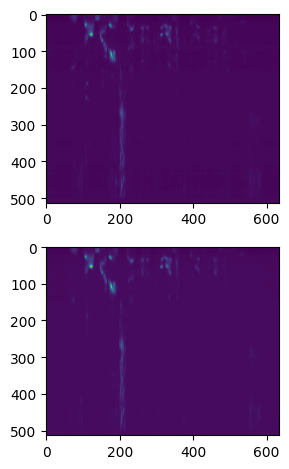

In [42]:
import librosa.display

idx = 0

fig, ax = plt.subplots(2, 1)
ax[0].imshow(sp_arrays[idx].T)
ax[1].imshow(model.predict(linguistic_arrays[idx])[1].T)

plt.tight_layout()

In [43]:
f0, sp, ap = model.predict(linguistic_arrays[idx])

20/20 [==============================] - 0s 2ms/step


In [44]:
mean = np.load("generated/acoustic/mean.npy")
std = np.load("generated/acoustic/std.npy")

def to_audio(f0, sp, ap):
    f0_mean, sp_mean, ap_mean = mean[0:1], mean[1:1+513], mean[1+513:]
    f0_std, sp_std, ap_std = std[0:1], std[1:1+513], std[1+513:]
    f0 = f0_mean + f0_std * f0
    sp = sp_mean + sp_std * sp
    ap = ap_mean + ap_std * ap
    audio = pw.synthesize(f0[:, 0].astype("double"), sp.astype("double"), ap.astype("double"), 22050)
    return audio

In [45]:
import pyworld as pw
import IPython

audio = to_audio(f0, sp, ap)
IPython.display.Audio(audio, rate=22050)

In [46]:
import pyworld as pw
import IPython

audio = to_audio(f0_arrays[idx], sp_arrays[idx], ap_arrays[idx])
IPython.display.Audio(audio, rate=22050)